We provide you with some helpers to load the dataset, as it requires specific processing.

In [ ]:
%%writefile requirements.txt
waveprop @ git+https://github.com/ebezzam/waveprop.git
slm_controller @ git+https://github.com/ebezzam/slm-controller.git
perlin_numpy @ git+https://github.com/pvigier/perlin-numpy.git@5e26837db14042e51166eb6cad4c0df2c1907016

In [ ]:
!pip install -r requirements.txt

In [1]:
%load_ext autoreload
%autoreload 2

from lensless_helpers.preprocessor import get_dataset_object, get_roi

Let's load an example from the dataset.

In [2]:
from datasets import load_dataset

dataset = load_dataset(
    "parquet",
    data_files={
        "test": "https://huggingface.co/datasets/bezzam/DigiCam-Mirflickr-MultiMask-10K/resolve/main/data/test-00000-of-00002.parquet"
    }
)["test"]

In [3]:
data_object = dataset[1]
lensless = data_object["lensless"]
lensed = data_object["lensed"]
mask_label = data_object["mask_label"]

Mask label 1


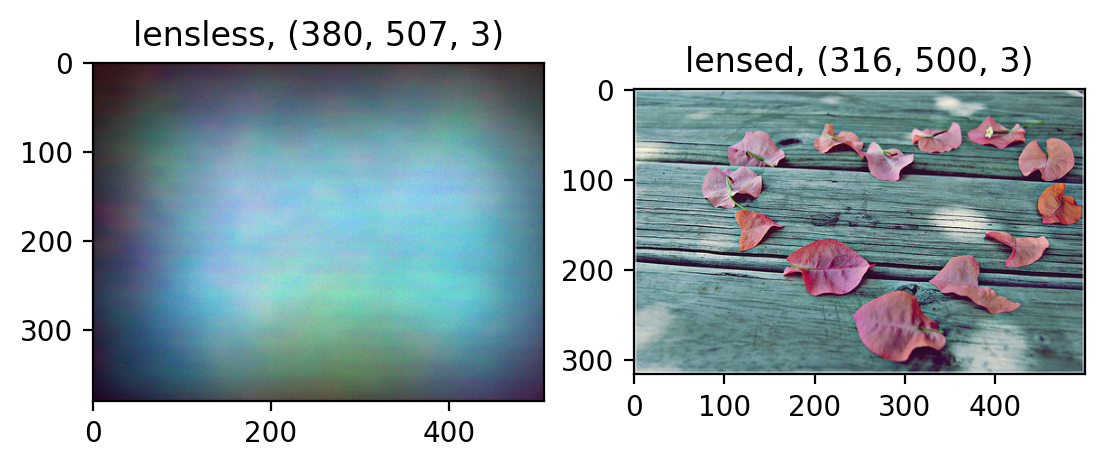

In [4]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

fig, axes = plt.subplots(1, 2)

axes[0].imshow(lensless)
axes[0].set_title(f"lensless, {np.array(lensless).shape}")
axes[1].imshow(lensed)
axes[1].set_title(f"lensed, {np.array(lensed).shape}")
print("Mask label", mask_label) 

PSFs are saved as mask patterns instead of PSF images. A special script is needed to convert patterns to PSF.

In [14]:
# We saw that the corresponding PSF mask has a label 1
# The dataset stores masks as f'mask_{label}.npy'

!wget https://huggingface.co/datasets/bezzam/DigiCam-Mirflickr-MultiMask-10K/resolve/main/masks/mask_1.npy

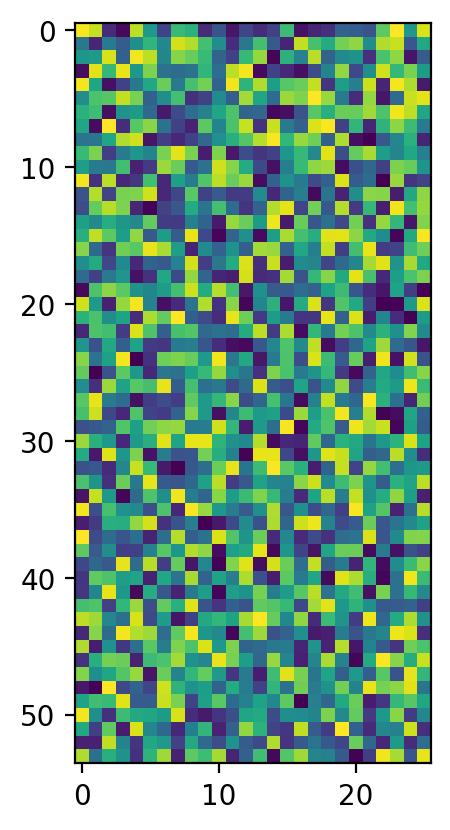

In [5]:
mask = np.load("mask_1.npy")

# mask is not a PSF, it is a pattern that defines LCD PSF
# we use special scripts to get PSF from it
plt.imshow(mask)

Let's use our code to:

1. Format lensed\lensless images.
2. Resize lensed image and put it on a "display", so the image is the same as the lensless camera "saw" it during capturing.
3. Convert mask pattern to an actual PSF.

In [6]:
lensed, lensless, psf = get_dataset_object(lensed, lensless, mask)

Mask label 1


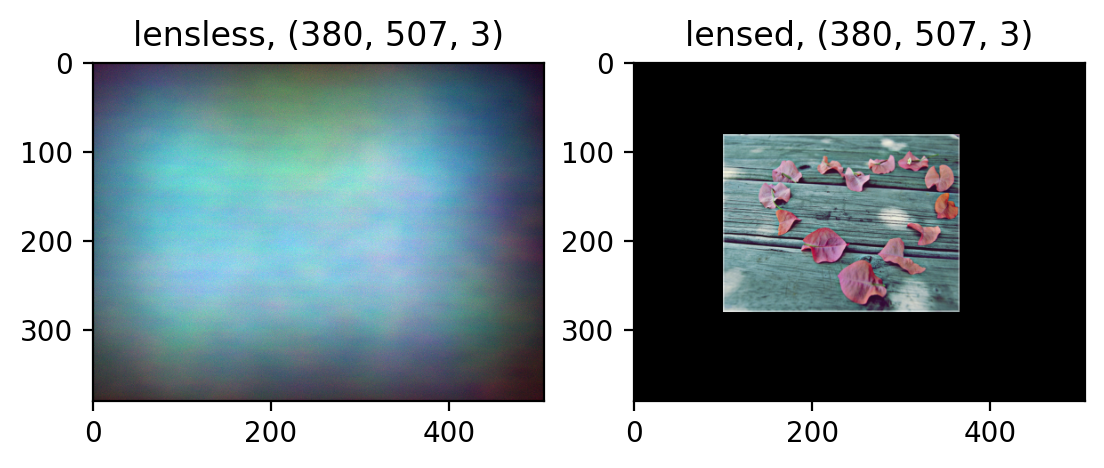

In [7]:
fig, axes = plt.subplots(1, 2)

axes[0].imshow(lensless)
axes[0].set_title(f"lensless, {np.array(lensless).shape}")
axes[1].imshow(lensed)
axes[1].set_title(f"lensed, {np.array(lensed).shape}")
print("Mask label", mask_label) 

tensor(0.0214) tensor(2.5762e-16)


Text(0.5, 1.0, 'Normalized PSF, torch.Size([1, 380, 507, 3])')

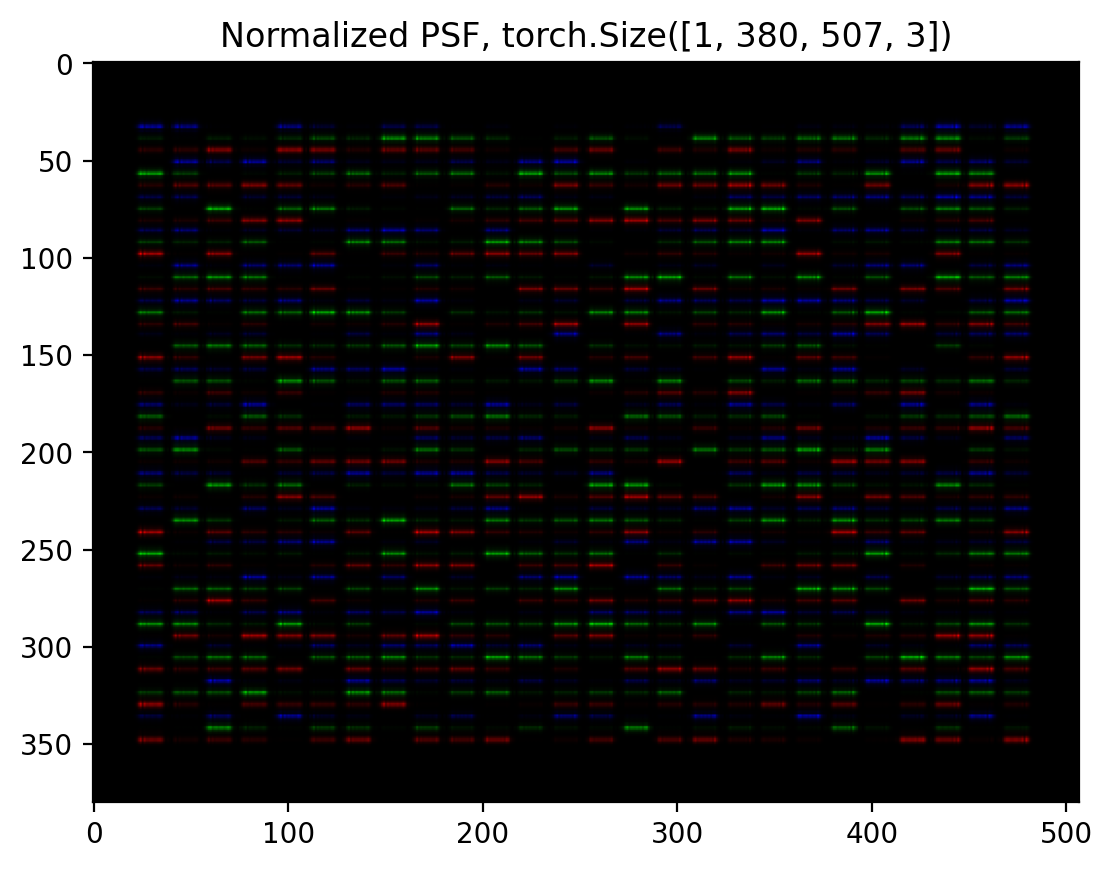

In [8]:
print(psf.max(), psf.min())
psf_for_plot = psf.clone() / psf.abs().max() # normalize
plt.imshow(psf_for_plot[0])
plt.title(f"Normalized PSF, {psf.shape}")

The reconstruction algorithm will reconstruct our object with this black borders as well (as in the lensed plot above). We need to extract Region of Interest (ROI). **Note**: loss and metrics must be calculated between ROI areas of lensed and reconstructed images.

Text(0.5, 1.0, 'ROI for lensed, torch.Size([200, 266, 3])')

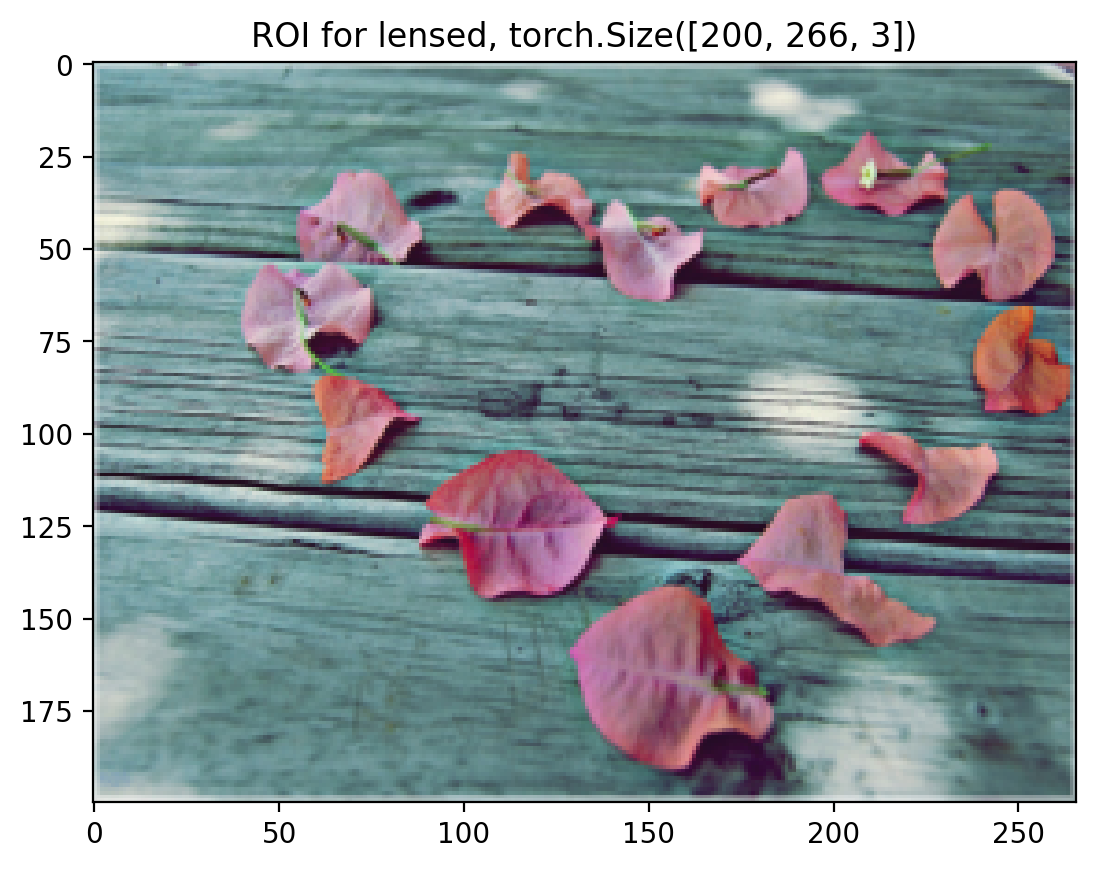

In [9]:
lensed_roi = get_roi(lensed)
plt.imshow(lensed_roi)
plt.title(f"ROI for lensed, {lensed_roi.shape}")